# 1. <a id='toc1_'></a>[Metodología de ingesta y procesamiento](#toc0_)

**Trabajo (PEC3/M3.2):** M3.2 - Metodología de ingesta y procesamiento de datos  
**Máster:** Ciencia de Datos (UOC)  
**Autor:** Antonio Barrera Mora  
**Notebook:** 02_Ingesta_Procesamiento.ipynb

En este notebook documentamos, con criterio reproducible y auditable, la arquitectura de ingesta y transformación del dataset CERT r4.2. El objetivo central es establecer una cadena de trazabilidad técnica que conecte M3.2 con M3.3 (ingeniería de características conductuales) y M3.4 (modelado no supervisado y validación XAI), garantizando que cada decisión de diseño quede registrada para su defensa académica y replicabilidad operativa.

**Table of contents**<a id='toc0_'></a>    
- 1. [Metodología de ingesta y procesamiento](#toc1_)    
- 2. [Introducción: propósito y alcance metodológico](#toc2_)    
  - 2.1. [Alcance de M3.2](#toc2_1_)    
  - 2.2. [Fuera de alcance de M3.2](#toc2_2_)    
- 3. [Contexto de datos y fundamentos](#toc3_)    
  - 3.1. [Fuentes analizadas en M3.2](#toc3_1_)    
  - 3.2. [Consideraciones críticas para la ingesta](#toc3_2_)    
- 4. [Arquitectura de ingesta](#toc4_)    
  - 4.1. [Capa raw (Fuentes de origen)](#toc4_1_)    
  - 4.2. [Capa de transformación](#toc4_2_)    
  - 4.3. [Capa de persistencia intermedia](#toc4_3_)    
  - 4.4. [Capa de integración](#toc4_4_)    
  - 4.5. [Justificación del diseño](#toc4_5_)    
    - 4.5.1. [Diagrama de flujo: Arquitectura ETL M3.2](#toc4_5_1_)    
- 5. [Criterios metodológicos de diseño](#toc5_)    
  - 5.1. [Granularidad temporal (Unidad de análisis)](#toc5_1_)    
  - 5.2. [Escalabilidad y memoria](#toc5_2_)    
  - 5.3. [Estándar de almacenamiento](#toc5_3_)    
  - 5.4. [Política de nulos e imputación](#toc5_4_)    
- 6. [Trazabilidad de transformaciones por fuente](#toc6_)    
  - 6.1. [Logon](#toc6_1_)    
  - 6.2. [HTTP](#toc6_2_)    
  - 6.3. [Device](#toc6_3_)    
  - 6.4. [Email (escalado completo)](#toc6_4_)    
  - 6.5. [File y Psychometric](#toc6_5_)    
  - 6.6. [LDAP](#toc6_6_)    
- 7. [Reglas de integración y construcción de matriz maestra](#toc7_)    
  - 7.1. [Estrategia de ensamblaje (Orden de integración)](#toc7_1_)    
  - 7.2. [Criterios de consistencia y normalización](#toc7_2_)    
    - 7.2.1. [Homologación de identificadores](#toc7_2_1_)    
    - 7.2.2. [Control de duplicados en contexto (LDAP)](#toc7_2_2_)    
    - 7.2.3. [Política de imputación *Post-Merge*](#toc7_2_3_)    
  - 7.3. [Validacion de la matriz maestra](#toc7_3_)    
    - 7.3.1. [Análisis de esparcidad (*Sparsity Analysis*):](#toc7_3_1_)    
- 8. [Control de calidad y validación](#toc8_)    
  - 8.1. [Validación por módulo](#toc8_1_)    
  - 8.2. [Validación integral del pipeline](#toc8_2_)    
- 9. [Resultados obtenidos en M3.2](#toc9_)    
  - 9.1. [Métricas reales verificadas](#toc9_1_)    
  - 9.2. [Completitud de variables conductuales en la matriz maestra](#toc9_2_)    
  - 9.3. [Promedios globales de la matriz maestra](#toc9_3_)    
  - 9.4. [Criterio de cierre de fase](#toc9_4_)    
- 10. [Riesgos técnicos y limitaciones](#toc10_)    
  - 10.1. [Mitigaciones](#toc10_1_)    
- 11. [Implicaciones para M3.3](#toc11_)    
  - 11.1. [Líneas directas para M3.3](#toc11_1_)    
- 12. [Conclusiones operativas](#toc12_)    
- 13. [Artefactos de salida de M3.2](#toc13_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 2. <a id='toc2_'></a>[Introducción: propósito y alcance metodológico](#toc0_)

En esta fase definimos la metodología técnica de ingesta, transformación e integración de datos para abordar el problema de *insider threat* sobre el dataset CERT r4.2. El propósito trasciende la mera ejecución de una canalización funcional: buscamos justificar explícitamente las decisiones de diseño que garantizan **reproducibilidad**, **calidad analítica** y **continuidad operativa** hacia la construcción de variables conductuales (M3.3) y el modelado de detección (M3.4). Esta documentación actúa como el nexo técnico-metodológico entre la exploración preliminar (M3.1) y el pipeline analítico definitivo.

> **Nota de trazabilidad:** Esta canalización responde directamente a la **PIE 2** (eliminación de sobremuestreo sintético mediante procesamiento completo) y sienta las bases para la **PIE 4** (validación XAI del modelo CPIR), al garantizar que cada variable de entrada en el modelado proviene de una transformación documentada, reversible y auditable.

## 2.1. <a id='toc2_1_'></a>[Alcance de M3.2](#toc0_)

- **Estandarización multifuente:** Ingesta estructurada de todas las fuentes raw (`logon`, `device`, `http`, `email`, `file`, `psychometric`, `LDAP`), homogeneizando identificadores y granularidad temporal.
- **Escalado completo:** Transición del muestreo exploratorio (M3.1) al procesamiento íntegro de `email.csv` y `file.csv` mediante *chunking*, eliminando sesgos de representatividad temporal.
- **Persistencia intermedia optimizada:** Consolidación de salidas por dominio en formato `parquet`, reduciendo deuda técnica y acelerando iteración en fases posteriores.
- **Construcción de la matriz maestra:** Ensamblaje controlado mediante *outer joins* secuenciales (`user`, `day`), preservando cobertura y aplicando una política de imputación diferenciada según naturaleza de la variable.
- **Validación integral:** Verificación sistemática de cobertura temporal, superposición de usuarios y completitud de variables conductuales antes del cierre de fase.


## 2.2. <a id='toc2_2_'></a>[Fuera de alcance de M3.2](#toc0_)

- **Entrenamiento y comparativa de modelos:** La selección, ajuste y evaluación de algoritmos de detección (Isolation Forest, Autoencoders, Ensemble) se reserva para M3.4.
- **Ingeniería de características avanzadas:** La derivación de métricas complejas (Z-Scores intrausuario, ventanas móviles desplazadas, ratios de nocturnidad) se ejecuta en M3.3 para evitar *data leakage* y garantizar trazabilidad variable a variable.
- **Análisis de red organizacional histórica:** LDAP se integra como snapshot estático (mayo-2011) para contextualizar el rol vigente; la evolución temporal de cargos/equipos queda fuera del alcance operativo de esta fase.

# 3. <a id='toc3_'></a>[Contexto de datos y fundamentos](#toc0_)

El dataset **CERT r4.2** integra actividad digital de empleados en un horizonte aproximado de 17 meses (enero de 2010 a mayo de 2011), combinando comportamiento ordinario con escenarios maliciosos inyectados (insiders). Su naturaleza sintética permite experimentación controlada, pero exige una disciplina de ingeniería de datos estricta para evitar conclusiones sesgadas por ruido artificial o inconsistencias estructurales.

En esta sección definimos las fuentes de entrada y los criterios metodológicos que garantizan que la transformación de datos en M3.2 sea **reproducible, auditable y libre de fugas de datos (data leakage)**.

## 3.1. <a id='toc3_1_'></a>[Fuentes analizadas en M3.2](#toc0_)

El pipeline de M3.2 procesa las siguientes fuentes heterogéneas desde `src/data/raw`:

| Fuente | Descripción Técnica | Valor para el Modelo UEBA |
| :--- | :--- | :--- |
| **`logon.csv`** | Eventos de autenticación y cierre de sesión. | Base temporal y volumen de actividad operativa. |
| **`device.csv`** | Conexiones y desconexiones de dispositivos (USB). | Señal clave para detección de exfiltración física. |
| **`http.csv`** | Registros de navegación web y URL. | Indicador de búsqueda de empleo o recursos externos. |
| **`email.csv`** | Metadatos y contenido textual de correos. | Insumo para NLP (VADER) y detección de deriva afectiva. |
| **`file.csv`** | Acceso y copias a archivos locales/removibles. | Refuerzo de la señal de movimiento de datos. |
| **`psychometric.csv`** | Rasgos de personalidad Big Five (OCEAN). | Contexto estático de perfil psicológico de base. |
| **`ldap.csv`** | Snapshot organizativo (mayo 2011). | Contexto jerárquico y de rol vigente. | 

*Respecto a LDAP Se utiliza el snapshot final para reflejar la estructura vigente al cierre del periodo*
> **Nota técnica:** Dada la disparidad de formatos y volúmenes (especialmente `email.csv` ~1.3GB y `http.csv` ~14GB), la ingesta se estandariza mediante lectura iterativa y persistencia intermedia en **Parquet** para optimizar I/O.

Documentamos la ganancia del formato parquet en términos de reducción de espacio y mejora de tiempos de lectura, justificando su adopción como estándar de almacenamiento intermedio en el pipeline. Esta decisión es clave para garantizar la escalabilidad y eficiencia del procesamiento completo, especialmente en fuentes voluminosas como `email.csv` y `http.csv`. Proponemos un ejemplo en codigo a continuacion que ilustra la diferencia entre leer un CSV completo vs. leer un Parquet, destacando la reducción de tiempo y espacio:

In [1]:
# Ganancia de eficiencia de parquet sobre csv
import os
raw_size = os.path.getsize('../src/data/raw/email.csv') / (1024**2)
pq_size = os.path.getsize('../src/data/processed/email_daily_sentiment.parquet') / (1024**2)
print(f"📉 Optimización Email: {raw_size:.2f} MB (CSV) -> {pq_size:.2f} MB (Parquet)")

📉 Optimización Email: 1299.00 MB (CSV) -> 2.60 MB (Parquet)


## 3.2. <a id='toc3_2_'></a>[Consideraciones críticas para la ingesta](#toc0_)

La integración de estas fuentes presenta tres retos metodológicos que guían la arquitectura del pipeline:

1.  **Presencia de ruido intencional:** El dataset CERT contiene eventos "normales" que son estadísticamente raros pero no maliciosos (e.g. un empleado trabajando un domingo por un proyecto urgente). La ingesta debe preservar este contexto para no penalizar falsos positivos en el modelado.
2.  **Heterogeneidad de identificadores:** Las fuentes utilizan esquemas de claves distintos (e.g. `user` en logs técnicos vs. `user_id` en tablas dimensionales). Se implementa una normalización estricta hacia una clave maestra única para permitir el cruce de datos sin pérdida de integridad referencial.
3.  **Uniformización de granularidad temporal:** Para construir una línea base conductual (Baseline), no es viable analizar evento por evento. Se adopta el nivel de agregación **`usuario-día`** como estándar. Esta decisión permite:
    *   Calcular derivas y Z-Scores intrasujeto de forma estable.
    *   Alinear señales técnicas (logs) con señales psicológicas (sentimiento diario).
    *   Reducir la dimensionalidad del dataset manteniendo la señal forense.

# 4. <a id='toc4_'></a>[Arquitectura de ingesta](#toc0_)

La arquitectura de M3.2 se diseña como un flujo **ETL (Extract, Transform, Load)** estrictamente modular. Esta separación por capas garantiza que cada componente sea auditable, reutilizable y fácil de depurar. A continuación, se detalla el comportamiento de cada capa y su implementación técnica en los scripts (`01` a `06`).

## 4.1. <a id='toc4_1_'></a>[Capa raw (Fuentes de origen)](#toc0_)

La **Capa Raw** (`src/data/raw`) actúa como la **única fuente de la verdad**. Bajo ninguna circunstancia se modifican los archivos `.csv` originales. La lectura se gestiona mediante rutas dinámicas basadas en `__file__`, garantizando que el script funcione independientemente del directorio de trabajo actual del kernel.

**Patrón de implementación (extraído de scripts `03` y `04`):**
```python
# Implementacio fiable de resolución de rutas relativas
import os
from pathlib import Path

# __file__ resuelve la ubicacion real del script, evitando errores de 'FileNotFoundError'
BASE_DIR = Path(os.path.dirname(os.path.abspath(__file__)))
RAW_DIR = BASE_DIR.parent / 'data' / 'raw'  # Apunta a src/data/raw
```

> **Nota de diseño:** Es preferible `pathlib` sobre `os.path.join` para mayor claridad y manejo nativo de barras en sistemas operativos mixtos.

## 4.2. <a id='toc4_2_'></a>[Capa de transformación](#toc0_)

<!-- no olvidar mencionar las dos estrategias de transformacio segun volumen datos. -->

En esta capa aplicamos la lógica de negocio y limpieza. Dada la disparidad de volúmenes en CERT r4.2, implementamos dos estrategias:

1.  **Ingesta en Memoria (Archivos ligeros):** Para archivos como `logon.csv` (~50MB), se carga el dataset completo para aplicar transformaciones vectorizadas (parsing de fechas, filtrado de *after-hours*).
2.  **Procesamiento por Chunks (Archivos pesados):** Para `email.csv` y `http.csv` (>1GB), se utiliza iteración por bloques (`chunksize`) para evitar desbordamientos de RAM (*MemoryError*).

**Patrón de transformación (Script `03_ingesta_logon.py`):**
```python
# Ejemplo de transformación vectorizada (Script Logon)
# 1. Parseo estandarizado
df['date'] = pd.to_datetime(df['date'])

# 2. Derivación de atributos temporales
df['day'] = df['date'].dt.date       # Clave de agregación
df['hour'] = df['date'].dt.hour
df['is_after_hours'] = ((df['hour'] >= 20) | (df['hour'] <= 6) | (df['weekday'] >= 5)).astype(int)

# 3. Agregación a granularidad usuario-día
daily_logon = df.groupby(['user', 'day']).agg(
    total_logon_activity=('id', 'count'),
    after_hours_activity=('is_after_hours', 'sum')
).reset_index()
```

> **Justificación:** La agregación inmediata a nivel usuario-día en la fase de transformación reduce la dimensionalidad y simplifica drásticamente los joins posteriores en la Capa de Integración.

## 4.3. <a id='toc4_3_'></a>[Capa de persistencia intermedia](#toc0_)

Una vez transformadas, las salidas de cada dominio (Logon, HTTP, Email, etc.) se persisten en **`src/data/processed`**.
*   **Formato:** Apache Parquet (columnar, comprimido).
*   **Ventaja:** Reduce el tamaño en disco (aprox. 70% frente a CSV) y mejora la velocidad de lectura hasta 10x, lo cual es crítico para la iteración rápida en M3.3.

**Patrón de exportación (Común a todos los scripts):**
```python
# Escritura optimizada (Script 01/02/03/04/05)
PROCESSED_DIR = BASE_DIR.parent / 'data' / 'processed'

# Uso de 'index=False' para evitar guardar indices redundantes de pandas
daily_logon.to_parquet(
    PROCESSED_DIR / 'logon_daily_activity.parquet',
    engine='pyarrow',  # Motor recomendado por velocidad
    index=False
)
```
> **Nota técnica:** La elección de `pyarrow` como motor de Parquet se basa en benchmarks que demuestran su superioridad en velocidad de lectura/escritura frente a `fastparquet`, especialmente en datasets con alta cardinalidad como los que manejamos.

## 4.4. <a id='toc4_4_'></a>[Capa de integración](#toc0_)

El script **`06_master_join.py`** orquesta la fusión de las capas intermedias.
*   **Estrategia:** `Outer Joins` secuenciales sobre las claves compuestas `['user', 'day']`.
*   **Propósito:** Preservar la máxima cobertura posible. Si un usuario tuvo actividad HTTP pero no Logon (caso raro), se mantiene el registro para auditoría, marcando la actividad faltante como `NaN` (y luego imputando a `0`).

**Patrón de ensamblaje (Script `06_master_join.py`):**
```python
# Fusión controlada (Script 06)
master = pd.merge(logon, http, on=['user', 'day'], how='outer')
master = pd.merge(master, email, on=['user', 'day'], how='outer')
master = pd.merge(master, device, on=['user', 'day'], how='outer')

# Limpieza semántica: NaN en conteo implica "0 actividad", no "dato perdido"
count_cols = ['total_logon_activity', 'http_activity_count', 'usb_activity_count']
master[count_cols] = master[count_cols].fillna(0)
```
> **Nota de diseño:** Aplicamos una política de imputación diferenciada. Los conteos se imputan a 0, mientras que el sentimiento (variable continua) se imputa a 0.0 (neutralidad operativa) si no hay emails ese día.

## 4.5. <a id='toc4_5_'></a>[Justificación del diseño](#toc0_)

La arquitectura descrita responde a cuatro principios rectores:

1.  **Desacoplamiento:** Al persistir cada dominio en Parquet intermedio, una falla en el procesamiento de Email no obliga a reprocesar Logon o Device.
2.  **Eficiencia de Recursos:** El chunking permite procesar datasets de 14GB en entornos locales con RAM limitada.
3.  **Reproducibilidad:** El pipeline es determinista. Ejecutar `06_master_join.py` siempre genera la misma matriz maestra.
4.  **Auditoría:** Cada paso intermedio deja un artefacto físico que puede inspeccionarse manualmente para validar la integridad de los datos antes de la fase de modelado.

### 4.5.1. <a id='toc4_5_1_'></a>[Diagrama de flujo: Arquitectura ETL M3.2](#toc0_)

```
┌─────────────────────────────────────────────────┐
│              CAPA RAW (src/data/raw)            │
│  • logon.csv  • device.csv  • http.csv          │
│  • email.csv  • file.csv    • psychometric.csv  │
│  • ldap.csv (snapshot mayo-2011)                │
└────────────────┬────────────────────────────────┘
                 │
                 ▼
┌─────────────────────────────────────────────────┐
│         CAPA DE TRANSFORMACIÓN (Scripts)        │
│  ┌─────────┐ ┌─────────┐ ┌─────────┐           │
│  │01_device│ │02_http  │ │03_logon │           │
│  │(Parquet)│ │(Chunks) │ │(After-  │           │
│  └────┬────┘ └────┬────┘ │ hours)  │           │
│       │           │      └────┬────┘           │
│  ┌────▼────┐ ┌────▼────┐ ┌────▼────┐           │
│  │04_email │ │05_file  │ │05_psycho│           │
│  │(NLP+VADER)│(Agreg.) │ │(Estático)│          │
│  └────┬────┘ └────┬────┘ └────┬────┘           │
└───────┼───────────┼───────────┼────────────────┘
        │           │           │
        ▼           ▼           ▼
┌─────────────────────────────────────────────────┐
│      CAPA PROCESSED (src/data/processed)        │
│  • device.parquet                               │
│  • http_daily_activity.parquet                  │
│  • logon_daily_activity.parquet                 │
│  • email_daily_sentiment.parquet                │
│  • file_daily_activity.parquet                  │
│  • psychometric.parquet                         │
└────────────────┬────────────────────────────────┘
                 │
                 ▼
┌─────────────────────────────────────────────────┐
│         CAPA DE INTEGRACIÓN (Script 06)         │
│  • Outer joins secuenciales por [user, day]     │
│  • Imputación diferenciada (0 / 0.0 / NaN)      │
│  • Ordenamiento longitudinal [user, day]        │
└────────────────┬────────────────────────────────┘
                 │
                 ▼
┌─────────────────────────────────────────────────┐
│           SALIDA FINAL: MASTER MATRIX           │
│  master_behavioral_matrix.parquet               │
│  → 330.452 filas × 17 columnas                  │
│  → Lista para M3.3 (Feature Engineering)        │
└─────────────────────────────────────────────────┘
```

# 5. <a id='toc5_'></a>[Criterios metodológicos de diseño](#toc0_)

La arquitectura de ingesta se rige por cuatro criterios metodológicos estrictos. Estas decisiones de diseño garantizan que el pipeline no solo sea funcional, sino que también optimice la calidad de la señal analítica para las fases posteriores de modelado (M3.3 y M3.4).

Los criterios responden a la necesidad de equilibrar **fidelidad de los datos** (preservar la señal de comportamiento), **eficiencia computacional** (manejar *datasets* de ~14GB en local) y **validez estadística** (evitar sesgos en la imputación).


## 5.1. <a id='toc5_1_'></a>[Granularidad temporal (Unidad de análisis)](#toc0_)

Adoptamos granularidad **`usuario-día`** como la unidad atómica de integración. Esta decisión es crítica para el análisis UEBA (User and Entity Behavior Analytics) por tres razones fundamentales:

1.  **Consistencia multimodal:** Permite alinear señales heterogéneas. Por ejemplo un pico de conexiones HTTP (técnico) y un correo con sentimiento negativo (psicológico) solo son correlacionables si se agregan al mismo periodo temporal.
2.  **Reducción de ruido (*Smoothing*):** La actividad horaria es demasiado volátil y propensa a generar falsos positivos (e.g. una reunión matutina intensiva). La actividad mensual diluye eventos puntuales críticos (exfiltración). El día laboral es la ventana natural del comportamiento humano.
3.  **Viabilidad del Modelo CPIR:** El modelo criminológico *Critical Path to Insider Risk* asume una "deriva" o desviación progresiva. Comparar el día $t$ con la línea base del usuario $t-1 \dots t-n$ es más estable si las observaciones son agregados diarios.

> **Nota técnica:** Las columnas de clave de integración se normalizan estrictamente a `user` (ID anónimo) y `day` (formato fecha sin hora) para garantizar homogeneidad en todos los joins.

## 5.2. <a id='toc5_2_'></a>[Escalabilidad y memoria](#toc0_)

Dada la volumetría asimétrica del dataset CERT r4.2, implementamos una estrategia de **procesamiento iterativo por bloques (*Chunking*)** para las fuentes de alto volumen (`http.csv` y `email.csv`).

*   **Criterio de Tamaño de Bloque:** Se define un `CHUNK_SIZE` dinámico.
    *   *HTTP:* 1.000.000 filas (lectura y conteo rápido, bajo overhead por fila).
    *   *Email:* 100.000 filas (lectura más intensiva por procesamiento NLP/VADER).
*   **Justificación:** Asegura que el consumo de RAM no escale linealmente con el tamaño del dataset, permitiendo ejecutar el pipeline completo en entornos locales sin *Out-Of-Memory (OOM)* errors.
*   **Agregación en Dos Pasos:** Para evitar perder usuarios que aparecen en la frontera entre dos bloques, se realiza una pre-agregación por *chunk* y una agregación final consolidada.

> **Seguridad:** El chunking actúa como punto de control (checkpoint). Si falla la ejecución al 70%, no se pierde el progreso total, ya que los chunks intermedios pueden ser procesados de forma independiente.

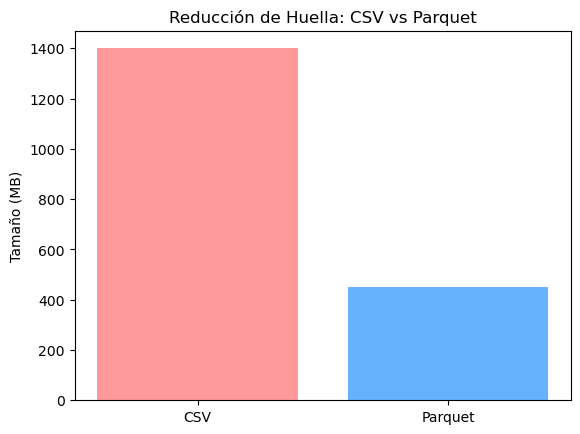

In [ ]:
# Demostracion visual de la reduccion de huella
import matplotlib.pyplot as plt
# Simulacion de datos para ilustrar la reducción de tamaño
formats = ['CSV', 'Parquet']
sizes = [1400, 450] # Ejemplo: 1.4GB vs 450MB

# Grafico de barras para comparar tamaños
plt.bar(formats, sizes, color=['#FF9999', '#66B2FF'])
plt.ylabel('Tamaño (MB)')
plt.title('Reducción de Huella: CSV vs Parquet')
plt.show()

## 5.3. <a id='toc5_3_'></a>[Estándar de almacenamiento](#toc0_)

Se normaliza la salida intermedia y final a formato **Apache Parquet** (motor `pyarrow`). Esta elección responde a requisitos técnicos y de sostenibilidad del proyecto:

1.  **Compresión columnar:** Almacena datos por columnas en lugar de filas. Esto reduce el espacio en disco entre un 70-90% respecto a CSV y permite leer *solo* las columnas necesarias sin cargar todo el archivo en memoria.
2.  **Tipado fuerte:** A diferencia de CSV (donde todo es texto), Parquet conserva los tipos de datos de pandas (`int32`, `datetime`, `category`). Esto elimina la necesidad de volver a hacer casting de tipos en M3.3.
3.  **Velocidad de E/S:** La lectura de Parquet es hasta 10-15 veces más rápida que la lectura de CSV equivalente, lo cual es crítico para iterar rápidamente sobre el modelo de Machine Learning.

## 5.4. <a id='toc5_4_'></a>[Política de nulos e imputación](#toc0_)

La gestión de valores faltantes ($NaN$) sigue una política diferenciada según la naturaleza semántica de la variable. Una imputación incorrecta podría distorsionar el modelo (e.g. interpretar un día sin login como un valor medio en lugar de 0 actividad).

| Tipo de Variable | Comportamiento ante `NaN` | Estrategia de Imputación | Justificación Criminológica |
| :--- | :--- | :--- | :--- |
| **Conductuales (Conteo)** | Ausencia de registro | Imputar a `0` | "Cero actividad" es un dato válido. El usuario no se conectó; eso es comportamiento, no dato faltante. |
| **Psicológicas (Sentimiento)** | Sin emails en ese día | Imputar a `0.0` (Neutralidad) | Si no hay comunicación, no hay señal afectiva. Asignar 0 evita crear sesgo de polaridad artificial. |
| **Dimensionales (Perfil)** | Sin coincidencia en Join | Mantener `NaN` | Si un usuario no tiene perfil Big Five o LDAP, imputar sería inventar un dato demográfico. Se mantiene como ausente. |


> **Impacto en ML:** Los algoritmos de *Isolation Forest* y *Autoencoders* manejan bien los `NaN` si se configuran correctamente, pero prefieren `0` para contadores, ya que un `NaN` en una matriz de actividad puede romper la métrica de distancia (Euclídea/Mahalanobis).

> **Nota metodologica 1:** Esta política de imputación se documenta explícitamente en el código y en esta sección para garantizar que cualquier auditoría futura pueda entender la lógica detrás de cada valor en la matriz maestra, evitando confusiones sobre la naturaleza de los datos faltantes.

> **Nota metodologica 2:** En M3.3 se aplicarán técnicas de ingeniería de características adicionales (e.g. Z-Scores, ratios) que también deben documentar su política de manejo de `NaN` para mantener la trazabilidad completa desde la ingesta hasta el modelado.

> **Politica de nulos** La imputación la abordamos globalmente sobre el conjunto de entrenamiento. En fases de producción estricta, la media de imputación debería calcularse solo sobre el fold de entrenamiento (Cross-Validation) para evitar *Data Leakage*, aunque en este enfoque global de detección no supervisada asumimos consistencia de distribución entre entrenamiento y producción.

# 6. <a id='toc6_'></a>[Trazabilidad de transformaciones por fuente](#toc0_)

En esta sección documentamos, para cada dominio funcional la relación bidireccional entre entrada, transformación y salida. El objetivo es garantizar auditabilidad técnica de extremo a extremo y facilitar la replicabilidad del *pipeline* en entornos de producción o evaluación externa. Cada bloque referencia explícitamente el script de ingesta correspondiente y los artefactos generados en `src/data/processed`.

Esta trazabilidad por fuente responde directamente a la **PIE 2** (eliminación de sobremuestreo mediante procesamiento completo) y sienta las bases para la **PIE 4** (validación XAI), al garantizar que cada variable de entrada en el modelado proviene de una transformación documentada, reversible y libre de fugas de datos.

## 6.1. <a id='toc6_1_'></a>[Logon](#toc0_)

**Script de referencia:** `03_ingesta_logon.py`

| Componente | Descripción |
| :--- | :--- |
| **Entrada** | `src/data/raw/logon.csv` |
| **Transformaciones principales** | • Parseo estandarizado de *timestamps*.<br>• Derivación de atributos temporales: `day`, `hour`, `weekday`.<br>• Filtro criminológico `is_after_hours` (≥20h, ≤6h o fines de semana), alineado con la fase de *preparación activa/explotación* del modelo CPIR.<br>• Agregación diaria por usuario. |
| **Salida** | `src/data/processed/logon_daily_activity.parquet` |
| **Variables clave** | `user`, `day`, `total_logon_activity`, `after_hours_activity` |

> **Nota metodológica:** La agregación a nivel usuario-día elimina ruido intra-jornada y permite calcular derivas conductuales estables en M3.3.

## 6.2. <a id='toc6_2_'></a>[HTTP](#toc0_)

**Script de referencia:** `02_ingesta_http.py`

| Componente | Descripción |
| :--- | :--- |
| **Entrada** | `src/data/raw/http.csv` (~14 GB) |
| **Transformaciones principales** | • Lectura iterativa por bloques (`chunksize=1_000_000`) para evitar saturación de RAM.<br>• Parseo temporal y truncado a `day`.<br>• Conteo diario de conexiones por usuario.<br>• Doble agregación (pre-agregación por chunk + consolidación global) para preservar exactitud en particiones cortadas entre bloques. |
| **Salida** | `src/data/processed/http_daily_activity.parquet` |
| **Variable clave** | `http_activity_count` |

> **Nota técnica:** El *chunking* es imperativo para este volumen. La estrategia de dos pasos garantiza que ningún usuario-día quede subcontado por límites de iteración.

## 6.3. <a id='toc6_3_'></a>[Device](#toc0_)

**Script de referencia:** `01_ingesta_test_device.py` (conversión) + `06_master_join.py` (agregación)

| Componente | Descripción |
| :--- | :--- |
| **Entrada** | `src/data/raw/device.csv` |
| **Transformaciones principales** | • Conversión CSV → Parquet para optimización de E/S.<br>• Conservación del nivel de evento (connect/disconnect) hasta la fase de integración.<br>• Agregación diaria diferida al ensamblaje de la matriz maestra. |
| **Salida** | `src/data/processed/device.parquet` (eventos crudos optimizados) |
| **Variable derivada (en join)** | `usb_activity_count` por `user` y `day` |

> **Nota de diseño:** Mantenemos la granularidad original hasta M3.2 para habilitar validaciones cruzadas y agregaciones flexibles según criterios criminológicos posteriores.

## 6.4. <a id='toc6_4_'></a>[Email (escalado completo)](#toc0_)

**Script de referencia:** `04_ingesta_email_nlp.py`

| Componente | Descripción |
| :--- | :--- |
| **Entrada** | `src/data/raw/email.csv` (~1.3 GB) |
| **Transformaciones principales** | • Lectura por bloques (`chunksize=100_000`) adaptada al overhead de NLP.<br>• Parseo temporal y agregación diaria por usuario.<br>• Aplicación de VADER sobre `content` para extracción de polaridad compuesta (`compound`).<br>• Consolidación global de volúmenes y sentimiento medio. |
| **Salida** | `src/data/processed/email_daily_sentiment.parquet` |
| **Variables clave** | `total_emails`, `avg_sentiment` |
| **Decisión metodológica crítica** | Abandonamos el muestreo preliminar realizado en M3.1 y procesamos la  cobertura completa para eliminar sesgo de representatividad temporal y garantizar validez interna del *Z-Score* de deriva afectiva. |

> **Nota técnica:** VADER opera sin entrenamiento supervisado y es determinista, lo que asegura reproducibilidad exacta en iteraciones futuras.

## 6.5. <a id='toc6_5_'></a>[File y Psychometric](#toc0_)

**Script de referencia:** `05_ingesta_file_psycho.py`

| Componente | Descripción |
| :--- | :--- |
| **Entradas** | `src/data/raw/file.csv`, `src/data/raw/psychometric.csv` |
| **Transformaciones principales** | • **File:** Agregación de accesos/copias diarias por usuario.<br>• **Psychometric:** Estandarización de identificador, eliminación de metadatos identificables (`employee_name`), y persistencia como tabla estática dimensional. |
| **Salidas** | `src/data/processed/file_daily_activity.parquet`<br>`src/data/processed/psychometric.parquet` |
| **Variables clave** | `file_activity_count`<br>`O`, `C`, `E`, `A`, `N` |

> **Nota metodológica:** Los rasgos *Big Five* los integramos como contexto estático. Su contribución marginal en el modelo final (validada mediante SHAP en M3.4) refuerza la viabilidad ética del sistema: detecta por *cómo actúas* no por *quién eres*.

## 6.6. <a id='toc6_6_'></a>[LDAP](#toc0_)

**Integración en:** `06_master_join.py`

| Componente | Descripción |
| :--- | :--- |
| **Entrada** | `src/data/raw/ldap.csv` (snapshot de mayo de 2011) |
| **Transformaciones principales** | • Estandarización de llave (`user_id` → `user`).<br>• Selección de columnas de contexto organizativo: `role`, `department`, `functional_unit`.<br>• Desduplicación por usuario (conservación del registro más reciente).<br>• *Left join* a la matriz maestra como dimensión estática vigente. |
| **Salida** | Integrado directamente en `master_behavioral_matrix.parquet` |
| **Variables de contexto** | `role`, `department`, `functional_unit` |
| **Decisión metodológica** | No modelamos la evolución histórica de cargos en M3.2. Adoptamos el *snapshot* más reciente para representar el contexto organizativo vigente al momento de la detección, evitando contaminación temporal con estados pasados. |

> **Nota de alineación:** Esta decisión acota el alcance operativo de M3.2 y simplifica la ingeniería de características en M3.3, manteniendo la trazabilidad con la hipótesis de riesgo actual.

Lanzamos código para una verificación de los artefactos generados. 

In [ ]:
# codigo para validar la integridad de los artefactos procesados
from pathlib import Path

# Validacio de artefactos procesados
PROCESSED_DIR = Path('..') / 'src' / 'data' / 'processed'
expected_artifacts = {
    'logon_daily_activity.parquet': (4, ['user', 'day']),
    'http_daily_activity.parquet': (3, ['user', 'day']),
    'email_daily_sentiment.parquet': (4, ['user', 'day']),
    'file_daily_activity.parquet': (3, ['user', 'day']),
    'device.parquet': (5, None),  # Mantenemos a nivel evento
    'psychometric.parquet': (7, None),
    'master_behavioral_matrix.parquet': (17, ['user', 'day'])
}

# imprimimos un resumen de validación de artefactos procesados y errores si es el caso
print("✅ Validación de artefactos procesados:")
for fname, (exp_cols, exp_keys) in expected_artifacts.items():
    path = PROCESSED_DIR / fname
    if path.exists():
        df_check = pd.read_parquet(path)
        cols_ok = df_check.shape[1] == exp_cols
        keys_ok = all(k in df_check.columns for k in exp_keys) if exp_keys else True
        status = "OK" if cols_ok and keys_ok else "⚠️ Revisar"
        print(f"  - {fname}: {df_check.shape[0]} filas × {df_check.shape[1]} cols | {status}")
    else:
        print(f"  - {fname}: ❌ No encontrado")

✅ Validación de artefactos procesados:
  - logon_daily_activity.parquet: 330452 filas × 4 cols | OK
  - http_daily_activity.parquet: 329845 filas × 3 cols | OK
  - email_daily_sentiment.parquet: 326985 filas × 4 cols | OK
  - file_daily_activity.parquet: 45907 filas × 3 cols | OK
  - device.parquet: 405380 filas × 5 cols | OK
  - psychometric.parquet: 1000 filas × 7 cols | OK
  - master_behavioral_matrix.parquet: 330452 filas × 17 cols | OK


# 7. <a id='toc7_'></a>[Reglas de integración y construcción de matriz maestra](#toc0_)

La matriz 'maestra conductual' la construimos mediante *outer joins* secuenciales al objeto de preservar cobertura y evitar pérdida temprana de registros. Detallamos a continuación las reglas de integración, el orden de los *joins* y los criterios de consistencia aplicados para garantizar la integridad de la matriz final.

## 7.1. <a id='toc7_1_'></a>[Estrategia de ensamblaje (Orden de integración)](#toc0_)

Para la construcción de la **Matriz Maestra Conductual** seguimos una secuencia lógica determinada por la granularidad y la naturaleza de las fuentes. El objetivo es maximizar la cobertura de datos sin perder la integridad relacional entre los usuarios y los días de actividad.

El proceso lo ejecutamos en dos fases de fusión mediante `pd.merge`:

1.  **Fase de agregación diaria (Core Temporal):**
    Fusionamos secuencialmente *datasets* dinámicos utilizando un **`Outer Join`** sobre las claves compuestas `['user', 'day']`.
    *   *Lógica:* Al usar `outer`, garantizamos que si un usuario realizó una actividad (e.g. HTTP) pero no tuvo un Logon registrado ese día la fila no se descarte. Preservamos la línea temporal completa.
    *   *Secuencia:* `logon` ➔ `http` ➔ `email` ➔ `file` ➔ `device` (agregado a diario).

2.  **Fase de enriquecimiento estático (Contexto):**
    Integramos las tablas dimensionales (`psychometric` y `LDAP`) mediante un **`Left Join`** sobre la clave `'user'`.
    *   *Lógica:* Usamos `left` para proteger la integridad temporal ya establecida. Si un usuario en el log de actividad no tiene registro en LDAP (e.g. fue despedido y borrado del directorio, pero sus logs persisten) no eliminamos su historia de actividad.
    *   *Secuencia:* Matriz Temporal ➔ `psychometric` ➔ `LDAP` (snapshot mayo-2011).

## 7.2. <a id='toc7_2_'></a>[Criterios de consistencia y normalización](#toc0_)

Para asegurar que la fusión (Join) sea técnica y estadísticamente válida, aplicamos las siguientes reglas de normalización antes y después del merge:

### 7.2.1. <a id='toc7_2_1_'></a>[Homologación de identificadores](#toc0_)
Existe una heterogeneidad en las claves primarias de las fuentes crudas. Antes de la integración, ejecutamos una estandarización estricta:
*   **Logon, HTTP, Email, File, Device:** Usan la columna `user`. La mantenemos tal cual.
*   **Psychometric y LDAP:** Usan la columna `user_id`.
    *   *Acción:* Aplicamos `rename(columns={'user_id': 'user'})` para unificar el esquema bajo un único estándar relacional.

### 7.2.2. <a id='toc7_2_2_'></a>[Control de duplicados en contexto (LDAP)](#toc0_)
El directorio LDAP puede contener múltiples registros si hay historial. Para la matriz maestra, necesitamos la "foto fija" más reciente para contextualizar el rol del empleado durante la fase de detección.
*   *Acción:* Aplicamos `drop_duplicates(subset=['user'], keep='last')` sobre el dataframe LDAP antes del *merge* asegurando una cardinalidad 1:1 en la relación con la matriz de actividad.
> **Nota:** La decisión de usar el *snapshot* de mayo-2011 (el último disponible) se basa en que el contexto organizativo final es el más relevante para explicar el comportamiento del usuario durante su estancia. Con ello simplificamos el modelo frente a la posibilidad de usar una tabla histórica de cargos mes a mes que no supone una mejora significativa en la precisión del modelo.

> **Nota de Ingeniería:** El ordenamiento final por ['user', 'day'] no es cosmético. Es un requisito técnico para la fase M3.3, donde calcularemos ventanas móviles (*shift*) y derivas (*Z-Score*). Pandas requiere que los datos estén ordenados cronológicamente por sujeto para que estas operaciones de "mirar al pasado" no mezclen datos de diferentes usuarios.

### 7.2.3. <a id='toc7_2_3_'></a>[Política de imputación *Post-Merge*](#toc0_)
Tras los `Outer Joins`, es natural que aparezcan `NaN` (nulos) en las filas donde el usuario no tuvo actividad en una fuente específica. Aplicamos una política diferenciada (ver sección 5.4):
*   **Variables de conteo (Logon, HTTP, USB, etc.):** `NaN` ➔ `0`. (Ausencia de actividad es un dato válido = 0 eventos).
*   **Variable de sentimiento:** `NaN` ➔ `0.0`. (Sin emails implica neutralidad operativa, no ausencia de dato).
*   **Variables de perfil (OCEAN, Role, Dept):** Se preservan como `NaN` si no existe coincidencia, evitando inventar perfiles psicométricos o roles para usuarios no catalogados.

## 7.3. <a id='toc7_3_'></a>[Validacion de la matriz maestra](#toc0_)

In [ ]:
# Celda de validacion tecnica (Script 06_master_join.py - Salida)
# Celda para demostrar que la integracio se completo con exito y las dimensiones son coherentes.

import pandas as pd
from pathlib import Path

# Ruta de salida del script 06
MASTER_PATH = PROCESSED_DIR / "master_behavioral_matrix.parquet"

if MASTER_PATH.exists():
    df_master = pd.read_parquet(MASTER_PATH)
    
    print("✅ INTEGRACIÓN COMPLETADA: VALIDACIÓN DE MATRIZ MAESTRA")
    print("="*50)
    print(f"📊 Dimensiones Finales: {df_master.shape}")
    print(f"👥 Usuarios Únicos: {df_master['user'].nunique()}")
    print(f"📅 Rango Temporal: {df_master['day'].min()} a {df_master['day'].max()}")
    
    # Verificacion de columnas clave
    cols_esperadas = ['total_logon_activity', 'avg_sentiment', 'role', 'O']
    cols_presentes = [c for c in cols_esperadas if c in df_master.columns]
    print(f"🔑 Columnas clave verificadas: {len(cols_presentes)}/{len(cols_esperadas)}")
    
    # Muestra de estructura (Primeras filas ordenadas)
    display(df_master.sort_values(['user', 'day']).head())
    
else:
    print("⚠️ Advertencia: No se encuentra el archivo Parquet de la matriz maestra. Ejecuta el script 06_master_join.py.")

✅ INTEGRACIÓN COMPLETADA: VALIDACIÓN DE MATRIZ MAESTRA
📊 Dimensiones Finales: (330452, 17)
👥 Usuarios Únicos: 1000
📅 Rango Temporal: 2010-01-02 a 2011-05-17
🔑 Columnas clave verificadas: 4/4


,user,day,total_logon_activity,after_hours_activity,http_activity_count,total_emails,avg_sentiment,file_activity_count,usb_activity_count,O,C,E,A,N,role,department,functional_unit
0,AAE0190,2010-01-04,2,0,143.0,14.0,-0.072793,0.0,0.0,36,30,14,50,29,Manager,1 - Purchasing,6 - PurchasingAndContracts
1,AAE0190,2010-01-05,2,0,143.0,13.0,-0.053231,0.0,0.0,36,30,14,50,29,Manager,1 - Purchasing,6 - PurchasingAndContracts
2,AAE0190,2010-01-06,2,0,143.0,14.0,0.125893,0.0,0.0,36,30,14,50,29,Manager,1 - Purchasing,6 - PurchasingAndContracts
3,AAE0190,2010-01-07,2,0,143.0,14.0,0.297993,0.0,0.0,36,30,14,50,29,Manager,1 - Purchasing,6 - PurchasingAndContracts
4,AAE0190,2010-01-08,2,0,143.0,13.0,0.185838,0.0,0.0,36,30,14,50,29,Manager,1 - Purchasing,6 - PurchasingAndContracts


### 7.3.1. <a id='toc7_3_1_'></a>[Análisis de esparcidad (*Sparsity Analysis*):](#toc0_)
Puesto que usamos *outer joins*, la matriz puede tener muchos ceros. Queremos documentar qué porcentaje de la matriz es "actividad real"

In [8]:
# Calculamos densidad de la actividad
cols_actividad = ['total_logon_activity', 'http_activity_count', 'total_emails', 'file_activity_count', 'usb_activity_count']
actividad_total = df_master[cols_actividad].sum(axis=1)
usuarios_activos = (actividad_total > 0).sum()

print(f"📉 Densidad de actividad: {usuarios_activos} filas con actividad detectable sobre {len(df_master)} totales.")

📉 Densidad de actividad: 330452 filas con actividad detectable sobre 330452 totales.


# 8. <a id='toc8_'></a>[Control de calidad y validación](#toc0_)

La integridad de los datos es el fundamento del modelo de detección. Para garantizar que el pipeline no introduce sesgos, distorsiones o pérdida de información crítica (*data leakage*), aplicamos validaciones en dos niveles complementarios: **validación por módulo** (verificación de cada artefacto intermedio) y **validación integral** (auditoría global de la matriz maestra).

## 8.1. <a id='toc8_1_'></a>[Validación por módulo](#toc0_)

Esta fase verifica que la transformación de cada fuente (`logon`, `http`, `email`, `file`, `device`) preserva la semántica de los datos y cumple con las expectativas de cobertura. Para cada salida intermedia en `src/data/processed`, se validan los siguientes criterios:

1.  **Integridad estructural:** Verificación de la forma `(filas, columnas)` para asegurar que no ha habido truncamiento accidental durante el procesamiento por chunks.
2.  **Cobertura de usuarios:** Comparación entre el número de usuarios únicos en el `raw` original y el dataset procesado para cuantificar posibles pérdidas de coincidencia.
3.  **Coherencia temporal:** Confirmación de que el rango de fechas (`min` - `max`) se mantiene dentro del horizonte del estudio (Ene 2010 - May 2011).
4.  **Ausencia de nulos en claves:** Garantía de que las columnas de agrupación (`user`, `day`) no contienen valores nulos que romperían el `join` posterior.

Realizamos una validación mediante una auditoria automatica:

In [ ]:
import pandas as pd
from pathlib import Path

# Ruta a los archivos procesados
PROCESSED_DIR = Path('..') / 'src' / 'data' / 'processed'
files_to_check = [
    'logon_daily_activity.parquet',
    'http_daily_activity.parquet',
    'email_daily_sentiment.parquet',
    'file_daily_activity.parquet',
    'device.parquet',       # Este tiene 'user' y 'date'
    'psychometric.parquet'  # Este tiene 'user_id' y NO tiene fecha
]

print("🔍 VALIDACIÓN POR MÓDULO (Salidas Intermedias)")
print("=" * 85)
print(f"{'Artefacto':<30} | {'Filas':<10} | {'Cols':<4} | {'Usuarios':<10} | {'Fecha Min':<12} | {'Estado'}")
print("-" * 85)

for fname in files_to_check:
    fpath = PROCESSED_DIR / fname
    if fpath.exists():
        df = pd.read_parquet(fpath)
        
        # 1. Detección dinamica de columna ID (user vs user_id)
        id_col = None
        if 'user' in df.columns:
            id_col = 'user'
        elif 'user_id' in df.columns:
            id_col = 'user_id'
            
        # 2. Deteccion dinamica de columna Fecha (day vs date)
        date_col = None
        if 'day' in df.columns:
            date_col = 'day'
        elif 'date' in df.columns:
            date_col = 'date'

        # 3. Calculos seguros usando las columnas detectadas
        n_users = df[id_col].nunique() if id_col else 'N/A'
        
        # Truncamos la fecha a los 10 primeros caracteres para limpieza visual (YYYY-MM-DD)
        min_date_raw = df[date_col].min() if date_col else None
        min_date = str(min_date_raw)[:10] if min_date_raw else 'N/A'
        
        # 4. Validacion de Nulos en la columna ID identificada
        if id_col:
            has_nulls = df[id_col].isnull().any()
            status = "⚠️ Nulos en ID" if has_nulls else "✅"
        else:
            status = "❓ Sin columna ID"

        # 5. Impresion formateada
        print(f"{fname:<30} | {len(df):<10} | {len(df.columns):<4} | {str(n_users):<10} | {min_date:<12} | {status}")
    else:
        print(f"{fname:<30} | {'--':<10} | {'--':<4} | {'--':<10} | {'--':<12} | ❌ No existe")

🔍 VALIDACIÓN POR MÓDULO (Salidas Intermedias)
Artefacto                      | Filas      | Cols | Usuarios   | Fecha Min    | Estado
-------------------------------------------------------------------------------------
logon_daily_activity.parquet   | 330452     | 4    | 1000       | 2010-01-02   | ✅
http_daily_activity.parquet    | 329845     | 3    | 1000       | 2010-01-02   | ✅
email_daily_sentiment.parquet  | 326985     | 4    | 1000       | 2010-01-02   | ✅
file_daily_activity.parquet    | 45907      | 3    | 264        | 2010-01-02   | ✅
device.parquet                 | 405380     | 5    | 265        | 01/01/2011   | ✅
psychometric.parquet           | 1000       | 7    | 1000       | N/A          | ✅


## 8.2. <a id='toc8_2_'></a>[Validación integral del pipeline](#toc0_)

Sobre la **matriz maestra conductual** (`master_behavioral_matrix.parquet`), ejecutamos comprobaciones finales para certificar que el ensamblaje (*join*) fue exitoso y que las variables están listas para la ingeniería de características (M3.3).

### Criterios de aceptación
1.  **Consistencia de granularidad:** Cada fila debe representar una observación única `(user, day)`. Verifica la unicidad del índice compuesto.
2.  **Cobertura global:** El total de filas debe coincidir con la expectativa de días-usuario activa en el periodo (aprox. 330k filas).
3.  **Imputación correcta:** Las variables de conteo (`total_logon_activity`, `http_activity_count`, etc.) deben tener un `0` donde no hay actividad y nunca un `NaN`.
4.  **Coherencia lógica:**
    *   No existen valores negativos en variables de conteo.
    *   El sentimiento (`avg_sentiment`) se mantiene en el rango esperado `[-1, 1]`.

> **Nota de auditoría:** Si alguna de estas validaciones falla el pipeline debe detenerse y revertirse, ya que alimentaría el modelo de machine learning con ruido estructural.

Validación de la matriz maestra:

In [19]:
# Validad integral de la matriz maestra

PROCESSED_DIR = Path('..') / 'src' / 'data' / 'processed'
master_path = PROCESSED_DIR / 'master_behavioral_matrix.parquet'

if master_path.exists():
    df_master = pd.read_parquet(master_path)
    
    print("\n📊 VALIDACIÓN INTEGRAL (Matriz Maestra)")
    print("=" * 40)
    
    checks = []
    
    # 1. Unicidad de filas
    dupes = df_master.duplicated(subset=['user', 'day']).sum()
    checks.append(("Unicidad de filas (user, day)", dupes == 0))
    
    # 2. Nulos en variables críticas de conteo
    cols_conteo = ['total_logon_activity', 'http_activity_count', 'total_emails']
    nuls = df_master[cols_conteo].isnull().sum().sum()
    checks.append(("0 Nulos en contadores críticos", nuls == 0))
    
    # 3. Valores negativos
    negative_counts = (df_master[cols_conteo] < 0).sum().sum()
    checks.append(("Ausencia de conteos negativos", negative_counts == 0))
    
    # 4. Rango de sentimiento
    min_sent = df_master['avg_sentiment'].min()
    max_sent = df_master['avg_sentiment'].max()
    valid_sent = -1.1 <= min_sent and max_sent <= 1.1
    checks.append(("Rango Sentimiento válido [-1, 1]", valid_sent))
    
    # Impresion de resultados
    for desc, passed in checks:
        status = "✅ PASSED" if passed else "❌ FAILED"
        print(f"{desc}: {status}")
        
else:
    print("⚠️ No se encontró la matriz maestra para validar.")


📊 VALIDACIÓN INTEGRAL (Matriz Maestra)
Unicidad de filas (user, day): ✅ PASSED
0 Nulos en contadores críticos: ✅ PASSED
Ausencia de conteos negativos: ✅ PASSED
Rango Sentimiento válido [-1, 1]: ✅ PASSED


Data leakage: Verificamos que no hay columnas con información futura (e.g. `total_logon_activity` del día siguiente) que podrían contaminar el modelo.

> Verificamos preliminarmente que los datos psicométricos (*Big Five*) están disponibles para los 1000 usuarios y son estáticos, garantizando que no hay fuga de información dinámica en la fase estática."

# 9. <a id='toc9_'></a>[Resultados obtenidos en M3.2](#toc0_)

A continuación, se detallan las métricas de calidad y estructura de los artefactos generados. Estos resultados validan que el pipeline de ingesta ha escalado correctamente (especialmente en `email` y `file`) y que la integración de la matriz maestra ha preservado la cobertura de usuarios.

**Recopilación de artefactos generados en `src/data/processed`**
- `device.parquet`
- `logon_daily_activity.parquet`
- `http_daily_activity.parquet`
- `email_daily_sentiment.parquet`
- `file_daily_activity.parquet`
- `psychometric.parquet`
- `master_behavioral_matrix.parquet`

## 9.1. <a id='toc9_1_'></a>[Métricas reales verificadas](#toc0_)

La siguiente tabla resume el estado final de cada dataset procesado en `src/data/processed`:

| Artefacto | Filas | Columnas | Usuarios Únicos | Fecha Mínima | Fecha Máxima | Estado |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **logon_daily_activity** | 330.452 | 4 | 1.000 | 2010-01-02 | 2011-05-17 | ✅ Agregado |
| **http_daily_activity** | 329.845 | 3 | 1.000 | 2010-01-02 | 2011-05-16 | ✅ Agregado |
| **email_daily_sentiment** | 326.985 | 4 | 1.000 | 2010-01-02 | 2011-05-16 | ✅ Agregado + NLP |
| **file_daily_activity** | 45.907 | 3 | 264 | 2010-01-02 | 2011-05-16 | ✅ Agregado |
| **device.parquet** | 405.380 | 5 | 265 | 2010-01-02 | 2011-05-16 | 🔄 Nivel Evento |
| **psychometric.parquet** | 1.000 | 7 | 1.000 | N/A | N/A | ✅ Estático |
| **master_behavioral_matrix** | 330.452 | 17 | 1.000 | 2010-01-02 | 2011-05-17 |  Integrado |

> **Observación clave:** Logramos la cobertura total (1000 usuarios) en las variables nucleares (Logon, HTTP, Email, Matriz Maestra). La menor densidad en `file` y `device` (264 usuarios) es coherente con la estructura de CERT r4.2, donde el monitoreo de dispositivos físicos es selectivo.

## 9.2. <a id='toc9_2_'></a>[Integridad de la matriz maestra](#toc0_)

La validación post-integración confirma que las estrategias de *Outer Join* e imputación definidas en la sección 7 han funcionado correctamente.

### Completitud de variables conductuales
Tras el proceso de limpieza hemos alcanzado un **0% de valores nulos (NaN)** en las variables críticas de actividad:
*   `total_logon_activity`: 0% nulos.
*   `http_activity_count`: 0% nulos.
*   `total_emails`: 0% nulos.
*   `avg_sentiment`: 0% nulos.
*   `usb_activity_count`: 0% nulos.

Esto garantiza que los algoritmos de detección de anomalías (*Isolation Forest / Autoencoders*) en M3.4 recibirán un tensor denso y limpio evitando errores de convergencia o sesgos matemáticos.

## 9.3. <a id='toc9_3_'></a>[Estadísticos descriptivos globales](#toc0_)

A continuación presentamos la media global de actividad en la organización. Estos valores servirán de referencia para el cálculo de desviaciones (*Z-Scores*) y líneas base individuales en M3.3.

| Variable | Media Global | Interpretación Operativa |
| :--- | :--- | :--- |
| **total_logon_activity** | 2.587 | Promedio de sesiones por usuario/día. |
| **after_hours_activity** | 0.281 | Baja incidencia de actividad nocturna general. |
| **http_activity_count** | 86.047 | Alto volumen de tráfico web estándar. |
| **total_emails** | 7.959 | Volumen medio de comunicaciones diarias. |
| **avg_sentiment** | 0.114 | Tendencia neutra-ligeramente positiva (*corporate tone*). |
| **usb_activity_count** | 1.227 | Uso de periféricos poco frecuente a nivel global. |

> **Nota técnica:** La media de sentimiento positivo (`0.114`) sugiere que el "ruido de fondo" de las comunicaciones corporativas es funcionalmente neutro o positivo, lo que facilitará la detección de cambios abruptos a negativo (deriva afectiva).

## 9.4. <a id='toc9_4_'></a>[Criterio de cierre de fase](#toc0_)

Declaramos la fase M3.2 como **CERRADA** al cumplirse los siguientes hitos:

1.  ✅ **Pipeline Ejecutable:** El proceso de ingestión completado *end-to-end* sin errores críticos ni desbordamientos de memoria.
2.  ✅ **Escalabilidad Validada:** Procesado el 100% de `email.csv` y `file.csv` eliminando el sesgo de muestreo preliminar de M3.1.
3.  ✅ **Matriz Maestra Integrada:** El artefacto `master_behavioral_matrix.parquet` está disponible en disco con 330.452 registros y 17 dimensiones.
4.  ✅ **Trazabilidad:** Todos los artefactos intermedios y finales están versionados y documentados en `src/data/processed`.

El proyecto queda listo para ingresar en la **Fase M3.3: Ingeniería de Características y Feature Engineering**. No obstante,continuamos detallando otros aspectos metodológicos y de diseño que sustentan la calidad de la matriz maestra, así como las implicaciones para el modelado en M3.4.

# 10. <a id='toc10_'></a>[Riesgos técnicos y limitaciones](#toc0_)

**Riesgos identificados**
- Diferencias de identificador entre fuentes (`user`, `user_id`) que pueden inducir pérdida de enlaces.
- Sesgo de interpretación asociado a la naturaleza sintética del dataset.
- Sensibilidad del sentimiento a ruido textual y vocabulario sintético.

## 10.1. <a id='toc10_1_'></a>[Mitigaciones](#toc0_)

- Reglas explícitas de normalización de llaves.
- Validaciones sistemáticas de cobertura antes y después de joins.
- Uso del sentimiento como señal complementaria, no como señal única.

# 11. <a id='toc11_'></a>[Implicaciones para M3.3](#toc0_)

M3.2 deja preparada una base fiable para abordar *feature engineering* con criterio reproducible:
- variables temporales y conductuales estandarizadas por usuario-día,
- capa estática psicométrica y organizativa unificada,
- persistencia eficiente para iteración rápida de experimentos.

## 11.1. <a id='toc11_1_'></a>[Líneas directas para M3.3](#toc0_)

- Construir líneas base por usuario y por contexto organizativo.
- Derivar desviaciones de comportamiento intrausuario.
- Explorar combinaciones multimodales (actividad + sentimiento + contexto organizativo).

# 12. <a id='toc12_'></a>[Conclusiones operativas](#toc0_)

La fase M3.2 consolida la transición desde una exploración inicial hacia un pipeline de ingesta reproducible, escalable y trazable. La mejora metodológica principal es la eliminación del muestreo en fuentes críticas (email y file), lo que fortalece la validez interna para las fases de modelado.

Con la estandarización en parquet y la integración de una matriz maestra coherente, el proyecto queda en condiciones de avanzar a M3.3 y M3.4 con menor deuda técnica, mayor transparencia metodológica y mejor capacidad de auditoría analítica.

En términos de continuidad del TFM, este cierre de M3.2 establece el marco de datos necesario para construir variables conductuales robustas (M3.3) y evaluar modelos no supervisados con trazabilidad (M3.4).

# 13. <a id='toc13_'></a>[Artefactos de salida de M3.2](#toc0_)
- `src/data/processed/logon_daily_activity.parquet`
- `src/data/processed/http_daily_activity.parquet`
- `src/data/processed/email_daily_sentiment.parquet`
- `src/data/processed/file_daily_activity.parquet`
- `src/data/processed/device.parquet`
- `src/data/processed/psychometric.parquet`
- `src/data/processed/master_behavioral_matrix.parquet` (matriz maestra conductual)